# BEE 4750 Homework 3: Dissolved Oxygen and Monte Carlo

**Name**: Matthew Burgos

**ID**: mb2557

> **Due Date**
>
> Thursday, 10/16/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to implement a model for dissolved oxygen in a
    river with multiple waste releases and use this to develop a
    strategy to ensure regulatory compliance.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Desktop/hw3-matty`


In [2]:
using Random
using Plots
using LaTeXStrings
using Distributions

## Problems (Total: 30 Points)

### Problem 1 (30 points)

A river which flows at 6 km/d is receiving waste discharges from two
sources which are 15 km apart. The oxygen reaeration rate is 0.55
day<sup>-1</sup>, and the decay rates of CBOD and NBOD are are 0.35 and
0.25 day<sup>-1</sup>, respectively. The river’s saturated dissolved
oxygen concentration is 10m g/L.

If the characteristics of the river inflow and waste discharges are
given in <a href="#tbl-river" class="quarto-xref">Table 1</a>, write a
Julia model to compute the dissolved oxygen concentration from the first
wastewater discharge to an arbitrary distance `d` km downstream. Use
your model to compute the minimum dissolved oxygen concentration up to
50 km downstream and how far downriver this maximum occurs.

| Parameter | River Inflow | Waste Stream 1 | Waste Stream 2 |
|:--:|---:|---:|---:|
| Inflow | 100,000 m<sup>3</sup>/d | 10,000 m<sup>3</sup>/d | 15,000 m<sup>3</sup>/d |
| DO Concentration | 7.5 mg/L | 5 mg/L | 5 mg/L |
| CBOD | 5 mg/L | 50 mg/L | 45 mg/L |
| NBOD | 5 mg/L | 35 mg/L | 35 mg/L |

Table 1: River inflow and waste stream characteristics for Problem 1.

### Problem 1.1

Implement the Streeter-Phelps (analytic) solution for the dissolved
oxygen concentration. Plot the dissolved oxygen concentration from the
first waste stream to 50 km downriver. What is the minimum value in
mg/L?


$$ C(x) = C_s(1-\alpha_1) + C_0\alpha_1 - B_0\alpha_2 - N_0\alpha_3 + (\frac{P-R-S_B}{k_a})(1-\alpha_1) $$

Assume P, R, and S are negligible

$$ C(x) = C_s(1-\alpha_1) + C_0\alpha_1 - B_0\alpha_2 - N_0\alpha_3  $$

$$ a_1 = exp(-\frac{k_ax}{U}) $$

$$ a_2 = (\frac{k_c}{k_a-k_c})[exp(\frac{-k_cx}{U})-exp(\frac{-k_ax}{U})] $$

$$ a_3 = (\frac{k_n}{k_a-k_n})[exp(\frac{-k_nx}{U})-exp(\frac{-k_ax}{U})] $$


The Streeter-Phelps equation was implemented below using the data from the table. To model the system, I had two separate equations: one before the second waste stream and one after the second waste stream. I used mass balances using the table to get the initial conditions for 0 km < x < 15 km. Then, I used the final state of the system at x=15 and data from the second waste stream to get the initial conditions for x > 15 km. I used a for-loop to iterate through each time step.

The minimum DO concentraion is 2.831981500888709 mg/L

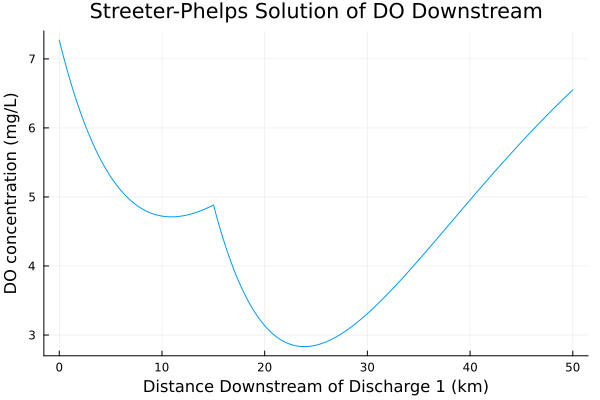

In [19]:
# Given

u = 6 #km/day
x_s2 = 15 #k
k_a = 0.55 #1/day
k_c = 0.35 #1/day
k_n = 0.25 #1/daym
c_s = 10 # mg/L

flow_r = 100000 #m^3/day
flow_s1 = 10000 #m^3/day
flow_s2 = 15000 #m^3/day

do_r = 7.5 #mg/L
do_s1 = 5 #mg/L
do_s2 = 5 #mg/L

cbod_r = 5 #mg/L
cbod_s1 = 50 #mg/L
cbod_s2 = 45 #mg/L

nbod_r = 5 #mg/L
nbod_s1 = 35 #mg/L
nbod_s2 = 35 #mg/L

# Create arrays for distances and respective DO concentration
iterations = 1000
distances = range(0, stop=50, length=iterations) 
do_concentrations = zeros(iterations)
do_concentrations2 = zeros(iterations+1)

# Calculate initial conditions for x < 15 km
c_0 = (flow_r*do_r + flow_s1*do_s1) / (flow_r+flow_s1)
do_concentrations2[1] = c_0
b_0 = (flow_r*cbod_r + flow_s1*cbod_s1) / (flow_r+flow_s1)
n_0 = (flow_r*nbod_r + flow_s1*nbod_s1) / (flow_r+flow_s1)

# Variable to check if second waste stream has started
flow2_started = false

for i in 1:iterations
    # x is the distance since the most recent waste stream
    if flow2_started == false
        x = distances[i]
    else
        x = distances[i] - 15
    end

    # Calculate alphas
    alpha_1 = exp(-k_a*x/u)
    alpha_2 = (k_c/(k_a-k_c) * (exp(-k_c*x/u) - exp(-k_a*x/u)))
    alpha_3 = (k_n/(k_a-k_n) * (exp(-k_n*x/u) - exp(-k_a*x/u)))

    # Calculate DO concentration and store in array
    c = c_s*(1-alpha_1) + c_0*alpha_1 - b_0*alpha_2 - n_0*alpha_3
    do_concentrations[i] = c

    # Change initial conditions if second waste stream has started
    if x > 15 && flow2_started == false
        c_0 = ((flow_r+flow_s1)*do_concentrations[i-1] + flow_s2*do_s2) / (flow_r+flow_s1+flow_s2)
        b_0 = ((flow_r+flow_s1)*(b_0*(1-alpha_2)) + flow_s2*cbod_s2) / (flow_r+flow_s1+flow_s2)
        n_0 = ((flow_r+flow_s1)*(n_0*(1-alpha_3)) + flow_s2*nbod_s2) / (flow_r+flow_s1+flow_s2)
        flow2_started = true
    end
end

# Find minimum value
print("The minimum DO concentraion is ", minimum(do_concentrations), " mg/L")

# Plot
plot(distances, do_concentrations, title="Streeter-Phelps Solution of DO Downstream", xlabel="Distance Downstream of Discharge 1 (km)", ylabel="DO concentration (mg/L)", legend=false)

Figure 1: Solution to the Streeter-Phelps equation with x=0 being at the first waste stream.

### Problem 1.2

Implement a numerically-integrated (discretized) solution for the
dissolved oxygen concentration. Using a resolution of 0.5km, conduct a
simulation and plot the results on the same axis as the plot from
Problem 1.1. How has the minimum value changed? What do you attribute
this difference to (be specific about the source of the difference(s) in
terms of the simulation dynamics, not just that one is a numerical
approximation).

$$ U\frac{dC}{dx} = k_a(C_s-C(x))+P-R-S_B-k_cB_0exp(-k_cx/U) - k_nN_0exp(-k_nx/U) $$

Assume P, R, and S are negligible

$$ U\frac{dC}{dx} = k_a(C_s-C(x))-k_cB_0exp(-k_cx/U) - k_nN_0exp(-k_nx/U) $$

$$ \frac{dC}{dx} = \frac{(k_a(C_s-C(x))-k_cB_0exp(-k_cx/U) - k_nN_0exp(-k_nx/U))}{U} $$

$$ C(x+\Delta x) = C(x) + \frac{dC}{dx} $$

The minimum DO concentraion for Streeter-Phelps is 2.822548543839264 mg/L
The minimum DO concentraion for numerical integration is 3.4747720458035976 mg/L

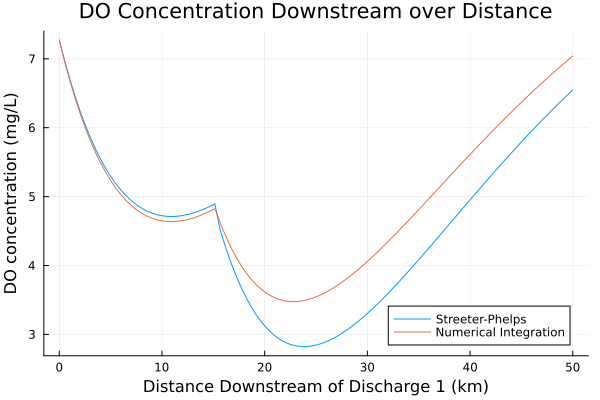

In [22]:
# Given

u = 6 #km/day
x_s2 = 15 #k
k_a = 0.55 #1/day
k_c = 0.35 #1/day
k_n = 0.25 #1/daym
c_s = 10 # mg/L

flow_r = 100000 #m^3/day
flow_s1 = 10000 #m^3/day
flow_s2 = 15000 #m^3/day

do_r = 7.5 #mg/L
do_s1 = 5 #mg/L
do_s2 = 5 #mg/L

cbod_r = 5 #mg/L
cbod_s1 = 50 #mg/L
cbod_s2 = 45 #mg/L

nbod_r = 5 #mg/L
nbod_s1 = 35 #mg/L
nbod_s2 = 35 #mg/L

# Create arrays for distances and respective DO concentration
iterations = round(Int, 50/0.5)
distances = range(0, 50, iterations) 
streeter_concentrations = zeros(iterations)
numerical_concentrations = zeros(iterations)

function streeter()
    # Calculate initial conditions for x < 15 km
    c_0 = (flow_r*do_r + flow_s1*do_s1) / (flow_r+flow_s1)
    b_0 = (flow_r*cbod_r + flow_s1*cbod_s1) / (flow_r+flow_s1)
    n_0 = (flow_r*nbod_r + flow_s1*nbod_s1) / (flow_r+flow_s1)

    # Variable to check if second waste stream has started
    flow2_started = false

    for i in 1:iterations
        # x is the distance since the most recent waste stream
        if flow2_started == false
            x = distances[i]
        else
            x = distances[i] - 15
        end

        # Calculate alphas
        alpha_1 = exp(-k_a*x/u)
        alpha_2 = (k_c/(k_a-k_c) * (exp(-k_c*x/u) - exp(-k_a*x/u)))
        alpha_3 = (k_n/(k_a-k_n) * (exp(-k_n*x/u) - exp(-k_a*x/u)))

        # Calculate DO concentration and store in array
        c = c_s*(1-alpha_1) + c_0*alpha_1 - b_0*alpha_2 - n_0*alpha_3
        streeter_concentrations[i] = c

        # Change initial conditions if second waste stream has started
        if x > 15 && flow2_started == false
            c_0 = ((flow_r+flow_s1)*streeter_concentrations[i-1] + flow_s2*do_s2) / (flow_r+flow_s1+flow_s2)
            b_0 = ((flow_r+flow_s1)*(b_0*(1-alpha_2)) + flow_s2*cbod_s2) / (flow_r+flow_s1+flow_s2)
            n_0 = ((flow_r+flow_s1)*(n_0*(1-alpha_3)) + flow_s2*nbod_s2) / (flow_r+flow_s1+flow_s2)
            flow2_started = true
        end
    end
end


function numerical()
    # Calculate initial conditions for x < 15 km
    c_0 = (flow_r*do_r + flow_s1*do_s1) / (flow_r+flow_s1)
    numerical_concentrations[1] = c_0 
    
    b_0 = (flow_r*cbod_r + flow_s1*cbod_s1) / (flow_r+flow_s1)
    n_0 = (flow_r*nbod_r + flow_s1*nbod_s1) / (flow_r+flow_s1)

    # Variable to check if second waste stream has started
    flow2_started = false

    for i in 1:iterations-1
        # x is the distance since the most recent waste stream
        if flow2_started == false
            x = distances[i]
        else
            x = distances[i] - 15
        end

        # Calculate DO concentration and store in array
        dcdx = (1/u)*(k_a*(c_s-numerical_concentrations[i]) - k_c*b_0*exp(-k_c*x/u) - k_n*n_0*exp(-k_n*x/u)) 
        numerical_concentrations[i+1] = numerical_concentrations[i] + 0.5*dcdx        
        
        # Change initial conditions if second waste stream has started
        if distances[i+1] > 15 && flow2_started == false
            c_0 = ((flow_r+flow_s1)*numerical_concentrations[i-1] + flow_s2*do_s2) / (flow_r+flow_s1+flow_s2)
            b_0 = ((flow_r+flow_s1)*(b_0-b_0*exp(-k_c*x/u)) + flow_s2*cbod_s2) / (flow_r+flow_s1+flow_s2)
            n_0 = ((flow_r+flow_s1)*(n_0-n_0*exp(-k_n*x/u)) + flow_s2*nbod_s2) / (flow_r+flow_s1+flow_s2)
            flow2_started = true
        end    
    end
end

streeter()
numerical()

# Find minimum value
print("The minimum DO concentraion for Streeter-Phelps is ", minimum(streeter_concentrations), " mg/L")
print("\n")
print("The minimum DO concentraion for numerical integration is ", minimum(numerical_concentrations), " mg/L")

# Plot
plot(distances, streeter_concentrations, title="DO Concentration Downstream over Distance", label="Streeter-Phelps", xlabel="Distance Downstream of Discharge 1 (km)", ylabel="DO concentration (mg/L)")
plot!(distances, numerical_concentrations, label="Numerical Integration", xlabel="Distance Downstream of Discharge 1 (km)", ylabel="DO concentration (mg/L)")



Figure 2: Plot comparing the Streeter-Phelps solution with numerical integration time step of 0.5 km.

As shown in the graph, the two different methods result in very different results. The numerical integration approach has a higher minimum concentraion of around 3.5 mg/L. This difference can be explained because the numerical integration approach is much more time-step-dependent (in this case, the time-step is a distance) than the Streeter Phelps solution. Numerical integration is iterative, so each new calculated concentration is based on the last concentration and the projected slope. This means that different time steps can significantly change the results. The Streeter Phelps solution is not iterative, meaning, once you know the initial conditions, you can know the concentation at any distance simply by plugging in x. With a relatively large delta x such as 0.5, the analytical solution will have more error than the Streeter Phelps solution.

### Problem 1.3

Using the analytic model, what is the minimum level of treatment (%
removal of organic waste; assume this is equivalent to the same level of
reduction of the CBOD and NBOD) for waste stream 1 that will ensure that
the dissolved oxygen concentration is in compliance with the 4 mg/L
standard along with a 5% margin of safety, assuming that waste stream 2
remains untreated? How about if only waste stream 2 is treated?

### Problem 1.4

Suppose you are responsible for designing a waste treatment plan for
discharges into the river, with a regulatory mandate to keep the
dissolved oxygen concentration above 4 mg/L. Discuss whether you’d opt
to treat waste stream 2 alone or both waste streams equally. What other
information might you need to make a conclusion, if any?

### Problem 1.5

Suppose that it is known that the DO concentrations at the river inflow
can vary according to a $\text{LogNormal}(2.0, 0.15)$ distribution.
Conduct a Monte Carlo simulation of the DO concentration in the river.
If you treat only waste stream 1 (based on your analysis from Problem
1.3), what is the expected probability and 95% confidence interval that
the river fails to comply with the regulatory standard of 4 mg/L? How
did you decide that your Monte Carlo sample size was sufficiently large?

## References

List any external references consulted, including classmates.